In [59]:
import pandas as pd
import numpy as np

1.将下面的字典创建为DataFrame

In [60]:
data = {"grammer":["Python","C","Java","GO",np.nan,"SQL","PHP","Python"],
"score":[1,2,np.nan,4,5,6,7,10]}

In [61]:
df = pd.DataFrame(data)
df

,grammer,score
0,Python,1.0
1,C,2.0
2,Java,NaN
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


2.提取含有字符串"Python"的行

In [62]:
#方法一
df[df['grammer'] == 'Python']

,grammer,score
0,Python,1.0
7,Python,10.0


In [63]:
#方法二
results = df['grammer'].str.contains("Python")
results.fillna(value=False,inplace = True)
df[results]

C:\Users\liuwenbo\AppData\Local\Temp\ipykernel_66396\1217461541.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results.fillna(value=False,inplace = True)


,grammer,score
0,Python,1.0
7,Python,10.0


3.输出df的所有列名

In [64]:
print(df.columns)

Index(['grammer', 'score'], dtype='object')


4.修改第二列列名为'popularity'

In [65]:
df.rename(columns={'score':'popularity'}, inplace = True)
df

,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,NaN
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


5.统计grammer列中每种编程语言出现的次数

In [66]:
df['grammer'].value_counts()

grammer
Python    2
C         1
Java      1
GO        1
SQL       1
PHP       1
Name: count, dtype: int64

6.将空值用上下值的平均值填充

In [67]:
df['popularity'] = df['popularity'].fillna(df['popularity'].interpolate())
df

,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


7.提取popularity列中值大于3的行

In [68]:
df[df['popularity'] > 3]

,grammer,popularity
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


8.按照grammer列进行去除重复值

In [69]:
df.drop_duplicates(['grammer'])

,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0


9.计算popularity列平均值

In [70]:
df['popularity'].mean()

4.75

10.将grammer列转换为list

In [71]:
df['grammer'].to_list()

['Python', 'C', 'Java', 'GO', nan, 'SQL', 'PHP', 'Python']

11.将DataFrame保存为EXCEL

In [72]:
df.to_excel('test.xlsx')

12.查看数据行列数

In [73]:
df.shape

(8, 2)

13.提取popularity列值大于3小于7的行

In [74]:
df[(df['popularity'] > 3) & (df['popularity'] < 7)]

,grammer,popularity
3,GO,4.0
4,NaN,5.0
5,SQL,6.0


14.交换两列位置

In [75]:
''' 方法1
'''
temp = df['popularity']
df.drop(labels=['popularity'], axis=1,inplace = True)
df.insert(0, 'popularity', temp)
df

,popularity,grammer
0,1.0,Python
1,2.0,C
2,3.0,Java
3,4.0,GO
4,5.0,NaN
5,6.0,SQL
6,7.0,PHP
7,10.0,Python


In [76]:
#方法2
cols = df.columns[[1,0]]
df = df[cols]
df


,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


15.提取popularity列最大值所在行

In [77]:
df[df['popularity'] == df['popularity'].max()]

,grammer,popularity
7,Python,10.0


16.查看最后5行数据

In [78]:
df.tail()

,grammer,popularity
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Python,10.0


17.删除最后一行数据

In [79]:
df.drop([len(df)-1],inplace=True)
df

C:\Users\liuwenbo\AppData\Local\Temp\ipykernel_66396\436684151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop([len(df)-1],inplace=True)


,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0


18.添加一行数据['Perl',6.6]

In [80]:
row={'grammer':'Perl','popularity':6.6}
df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
df


,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
6,PHP,7.0
7,Perl,6.6


19.对数据按照"popularity"列值的大小进行排序

In [81]:
df.sort_values("popularity",inplace=True)
df

,grammer,popularity
0,Python,1.0
1,C,2.0
2,Java,3.0
3,GO,4.0
4,NaN,5.0
5,SQL,6.0
7,Perl,6.6
6,PHP,7.0


20.统计grammer列每个字符串的长度

In [82]:
df['grammer'] = df['grammer'].fillna('R')
df['len_str'] = df['grammer'].map(lambda x: len(x))
df

,grammer,popularity,len_str
0,Python,1.0,6
1,C,2.0,1
2,Java,3.0,4
3,GO,4.0,2
4,R,5.0,1
5,SQL,6.0,3
7,Perl,6.6,4
6,PHP,7.0,3


# Pandas数据处理

21.读取本地EXCEL数据

In [83]:
df = pd.read_excel('pandas120.xlsx')

22.查看df数据前5行

In [84]:
df.head()

,createTime,education,salary
0,2020-03-16 11:30:18,本科,20k-35k
1,2020-03-16 10:58:48,本科,20k-40k
2,2020-03-16 10:46:39,不限,20k-35k
3,2020-03-16 10:45:44,本科,13k-20k
4,2020-03-16 10:20:41,本科,10k-20k


23.将salary列数据转换为最大值与最小值的平均值

In [85]:
# 方法一：apply + 自定义函数
def func(df):
 lst = df['salary'].split('-')
 smin = int(lst[0].strip('k'))
 smax = int(lst[1].strip('k'))
 df['salary'] = int((smin + smax) / 2 * 1000)
 return df
df = df.apply(func,axis=1)
df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


24.将数据根据学历进行分组并计算平均薪资

In [86]:
print(df.groupby('education').mean())

                             createTime        salary
education                                            
不限        2020-03-16 10:36:09.200000000  19600.000000
大专        2020-03-16 10:24:02.000000000  10000.000000
本科        2020-03-16 10:15:28.302521088  19361.344538
硕士        2020-03-16 10:17:21.857142784  20642.857143


25.将createTime列时间转换为月-日

In [87]:
for i in range(len(df)):
 df.iloc[i,0] = df.iloc[i,0].to_pydatetime().strftime("%m-%d")
df.head()

C:\Users\liuwenbo\AppData\Local\Temp\ipykernel_66396\3826654624.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '03-16' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.iloc[i,0] = df.iloc[i,0].to_pydatetime().strftime("%m-%d")


,createTime,education,salary
0,03-16,本科,27500
1,03-16,本科,30000
2,03-16,不限,27500
3,03-16,本科,16500
4,03-16,本科,15000


26.查看索引、数据类型和内存信息

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   createTime  135 non-null    object
 1   education   135 non-null    object
 2   salary      135 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.3+ KB


27.查看数值型列的汇总统计

In [89]:
df.describe()

,salary
count,135.000000
mean,19159.259259
std,8661.686922
min,3500.000000
25%,14000.000000
50%,17500.000000
75%,25000.000000
max,45000.000000


28.新增一列根据salary将数据分为三组

In [90]:
bins = [0,5000, 20000, 50000]
group_names = ['低', '中', '高']
df['categories'] = pd.cut(df['salary'], bins, labels=group_names)
df

,createTime,education,salary,categories
0,03-16,本科,27500,高
1,03-16,本科,30000,高
2,03-16,不限,27500,高
3,03-16,本科,16500,中
4,03-16,本科,15000,中
...,...,...,...,...
130,03-16,本科,14000,中
131,03-16,硕士,37500,高
132,03-16,本科,30000,高
133,03-16,本科,19000,中


29.按照salary列对数据降序排列

In [91]:
df.sort_values('salary', ascending=False)

,createTime,education,salary,categories
53,03-16,本科,45000,高
37,03-16,本科,40000,高
101,03-16,本科,37500,高
16,03-16,本科,37500,高
131,03-16,硕士,37500,高
...,...,...,...,...
123,03-16,本科,4500,低
126,03-16,本科,4000,低
110,03-16,本科,4000,低
96,03-16,不限,3500,低


30.取出第33行数据

In [92]:
df.loc[32]

createTime    03-16
education        硕士
salary        22500
categories        高
Name: 32, dtype: object

31.计算salary列的中位数

In [93]:
np.median(df['salary'])

17500.0

32.绘制薪资水平频率分布直方图

<Axes: ylabel='Frequency'>

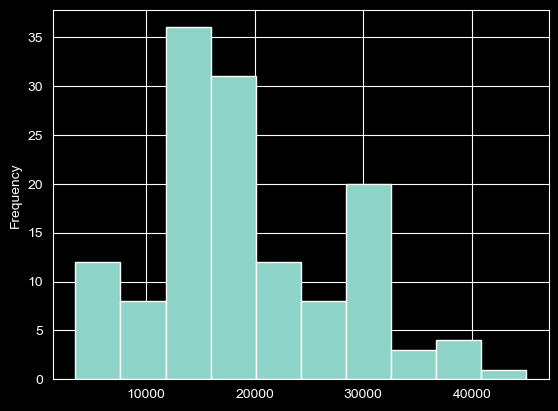

In [94]:
#执行两次
df.salary.plot(kind='hist')

33.绘制薪资水平密度曲线

<Axes: ylabel='Density'>

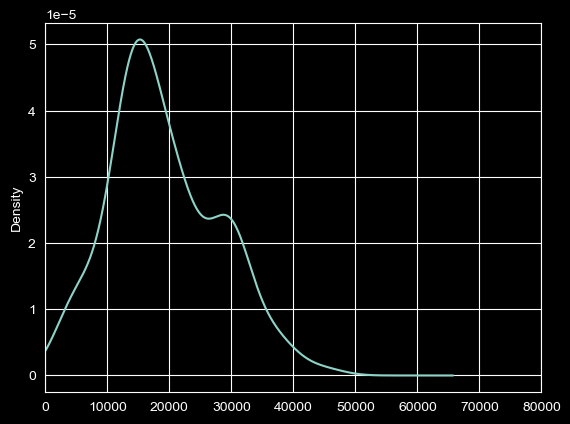

In [95]:
df.salary.plot(kind='kde',xlim=(0,80000))

34.删除最后一列categories

In [96]:
del df['categories']
# 等价于
# df.drop(columns=['categories'], inplace=True)
df

,createTime,education,salary
0,03-16,本科,27500
1,03-16,本科,30000
2,03-16,不限,27500
3,03-16,本科,16500
4,03-16,本科,15000
...,...,...,...
130,03-16,本科,14000
131,03-16,硕士,37500
132,03-16,本科,30000
133,03-16,本科,19000


35.将df的第一列与第二列合并为新的一列

In [97]:
df['test'] = df['education']+df['createTime']
df

,createTime,education,salary,test
0,03-16,本科,27500,本科03-16
1,03-16,本科,30000,本科03-16
2,03-16,不限,27500,不限03-16
3,03-16,本科,16500,本科03-16
4,03-16,本科,15000,本科03-16
...,...,...,...,...
130,03-16,本科,14000,本科03-16
131,03-16,硕士,37500,硕士03-16
132,03-16,本科,30000,本科03-16
133,03-16,本科,19000,本科03-16


36.将education列与salary列合并为新的一列

In [98]:
df["test1"] = df["salary"].map(str) + df['education']
df
#备注：salary为int类型，操作与35题有所不同

,createTime,education,salary,test,test1
0,03-16,本科,27500,本科03-16,27500本科
1,03-16,本科,30000,本科03-16,30000本科
2,03-16,不限,27500,不限03-16,27500不限
3,03-16,本科,16500,本科03-16,16500本科
4,03-16,本科,15000,本科03-16,15000本科
...,...,...,...,...,...
130,03-16,本科,14000,本科03-16,14000本科
131,03-16,硕士,37500,硕士03-16,37500硕士
132,03-16,本科,30000,本科03-16,30000本科
133,03-16,本科,19000,本科03-16,19000本科


37.计算salary最大值与最小值之差

In [99]:
df[['salary']].apply(lambda x: x.max() - x.min())

salary    41500
dtype: int64

38.将第一行与最后一行拼接

In [100]:
pd.concat([df[:1], df[-2:-1]])

,createTime,education,salary,test,test1
0,03-16,本科,27500,本科03-16,27500本科
133,03-16,本科,19000,本科03-16,19000本科


39.将第8行数据添加至末尾

In [101]:
pd.concat([df, df.iloc[[7]]])

,createTime,education,salary,test,test1
0,03-16,本科,27500,本科03-16,27500本科
1,03-16,本科,30000,本科03-16,30000本科
2,03-16,不限,27500,不限03-16,27500不限
3,03-16,本科,16500,本科03-16,16500本科
4,03-16,本科,15000,本科03-16,15000本科
...,...,...,...,...,...
131,03-16,硕士,37500,硕士03-16,37500硕士
132,03-16,本科,30000,本科03-16,30000本科
133,03-16,本科,19000,本科03-16,19000本科
134,03-16,本科,30000,本科03-16,30000本科


40.查看每列的数据类型

In [102]:
df.dtypes

createTime    object
education     object
salary         int64
test          object
test1         object
dtype: object

41.将createTime列设置为索引

In [103]:
df.set_index("createTime")

,education,salary,test,test1
createTime,,,,
03-16,本科,27500,本科03-16,27500本科
03-16,本科,30000,本科03-16,30000本科
03-16,不限,27500,不限03-16,27500不限
03-16,本科,16500,本科03-16,16500本科
03-16,本科,15000,本科03-16,15000本科
...,...,...,...,...
03-16,本科,14000,本科03-16,14000本科
03-16,硕士,37500,硕士03-16,37500硕士
03-16,本科,30000,本科03-16,30000本科


42.生成一个和df长度相同的随机数dataframe

In [104]:
df1 = pd.DataFrame(pd.Series(np.random.randint(1, 10, 135)))
df1

,0
0,1
1,3
2,3
3,7
4,7
...,...
130,3
131,7
132,7
133,3


43.将上一题生成的dataframe与df合并

In [105]:
df= pd.concat([df,df1],axis=1)
df

,createTime,education,salary,test,test1,0
0,03-16,本科,27500,本科03-16,27500本科,1
1,03-16,本科,30000,本科03-16,30000本科,3
2,03-16,不限,27500,不限03-16,27500不限,3
3,03-16,本科,16500,本科03-16,16500本科,7
4,03-16,本科,15000,本科03-16,15000本科,7
...,...,...,...,...,...,...
130,03-16,本科,14000,本科03-16,14000本科,3
131,03-16,硕士,37500,硕士03-16,37500硕士,7
132,03-16,本科,30000,本科03-16,30000本科,7
133,03-16,本科,19000,本科03-16,19000本科,3


44.生成新的一列new为salary列减去之前生成随机数列

In [106]:
df["new"] = df["salary"] - df[0]
df

,createTime,education,salary,test,test1,0,new
0,03-16,本科,27500,本科03-16,27500本科,1,27499
1,03-16,本科,30000,本科03-16,30000本科,3,29997
2,03-16,不限,27500,不限03-16,27500不限,3,27497
3,03-16,本科,16500,本科03-16,16500本科,7,16493
4,03-16,本科,15000,本科03-16,15000本科,7,14993
...,...,...,...,...,...,...,...
130,03-16,本科,14000,本科03-16,14000本科,3,13997
131,03-16,硕士,37500,硕士03-16,37500硕士,7,37493
132,03-16,本科,30000,本科03-16,30000本科,7,29993
133,03-16,本科,19000,本科03-16,19000本科,3,18997


45.检查数据中是否含有任何缺失值

In [107]:
df.isnull().values.any()

False

46.将salary列类型转换为浮点数

In [108]:
df['salary'].astype(np.float64)

0      27500.0
1      30000.0
2      27500.0
3      16500.0
4      15000.0
        ...   
130    14000.0
131    37500.0
132    30000.0
133    19000.0
134    30000.0
Name: salary, Length: 135, dtype: float64

47.计算salary大于10000的次数

In [109]:
len(df[df['salary']>10000])

119

48.查看每种学历出现的次数

In [110]:
df.education.value_counts()

education
本科    119
硕士      7
不限      5
大专      4
Name: count, dtype: int64

49.查看education列共有几种学历

In [111]:
df['education'].nunique()

4

50.提取salary与new列的和大于60000的最后3行

In [112]:
df1 = df[['salary','new']]
rowsums = df1.apply(np.sum, axis=1)
res = df.iloc[np.where(rowsums > 60000)[0][-3:], :]
res

,createTime,education,salary,test,test1,0,new
92,03-16,本科,35000,本科03-16,35000本科,5,34995
101,03-16,本科,37500,本科03-16,37500本科,2,37498
131,03-16,硕士,37500,硕士03-16,37500硕士,7,37493


 ## 第二题

### 第一问

In [113]:
df = pd.read_csv('house.csv')
df.head(3)

,floor,year,area,price
0,高层（共6层）,1986年建,58.23㎡,155万
1,中层（共20层）,2020年建,88㎡,155万
2,低层（共28层）,2010年建,89.33㎡,365万


In [114]:
df['year'] = df['year'].str.extract(r'(\d{4})').astype('Int64')
df['year']

0        1986
1        2020
2        2010
3        2014
4        2015
         ... 
31563    2010
31564    2006
31565    2011
31566    2006
31567    2008
Name: year, Length: 31568, dtype: Int64

### 第二问

In [1]:
df['Level'] = df['floor'].str.extract(r'(高层|中层|低层)')
df['Highest'] = df['floor'].str.extract(r'共(\d+)层').astype('Int64')
df = df.drop('floor', axis=1)
df

NameError: name 'df' is not defined

### 第三问

In [116]:
df['price_num'] = df['price'].str.extract(r'(\d+)').astype(float) * 10000
# 提取面积中的数字部分
df['area_num'] = df['area'].str.extract(r'(\d+\.?\d*)').astype(float)
# 计算每平米均价并格式化
df['avg_price'] = (df['price_num'] / df['area_num']).round().astype(str) + '元/平米'
df

,year,area,price,Level,Highest,price_num,area_num,avg_price
0,1986,58.23㎡,155万,高层,6,1550000.0,58.23,26619.0元/平米
1,2020,88㎡,155万,中层,20,1550000.0,88.00,17614.0元/平米
2,2010,89.33㎡,365万,低层,28,3650000.0,89.33,40860.0元/平米
3,2014,82㎡,308万,低层,20,3080000.0,82.00,37561.0元/平米
4,2015,98㎡,117万,高层,1,1170000.0,98.00,11939.0元/平米
...,...,...,...,...,...,...,...,...
31563,2010,391.13㎡,10000万,中层,39,100000000.0,391.13,255669.0元/平米
31564,2006,283㎡,2600万,高层,54,26000000.0,283.00,91873.0元/平米
31565,2011,245㎡,2500万,高层,16,25000000.0,245.00,102041.0元/平米
31566,2006,284㎡,3500万,高层,62,35000000.0,284.00,123239.0元/平米
